# Forward Contracts

This notebook introduces forward contracts and applies the forward-spot parity to different assets.

## Load Packages and Extra Functions

In [1]:
using Printf

include("src/printmat.jl");

In [2]:
using Plots
default(size = (480,320),fmt = :png)

# Present Value

With a continuously compounded interest rate $y$, the present value of receiving $Z$ in $m$ years is 

$e^{-my}Z$.

In [3]:
(y,m,Z)  = (0.05,3/4,100)
PV = exp(-m*y)*Z

printlnPs("PV of $Z when m=$m and y=$y: ",PV)

PV of 100 when m=0.75 and y=0.05:     96.319


# Payoff of Forward Contract

The payoff of a forward contract (at expiration, $m$ years ahead) is $S_{m}-F$, where $S_m$ is the value of the underlying (at expiration) and $F$ is the forward price (agreed upon at inception of the contract).

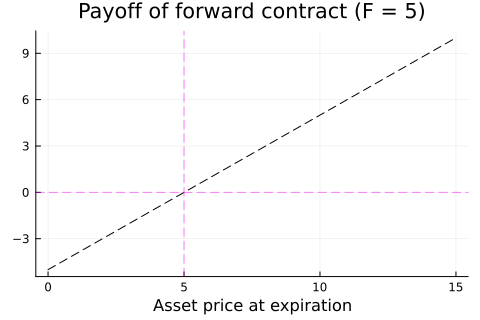

In [4]:
Sₘ_range = range(0,15,length=16)   #possible values of the underlying price at expiration
F  = 5
ForwardPayoff = Sₘ_range .- F

p1 = plot( Sₘ_range,ForwardPayoff,
           linecolor = :black,
           linestyle = :dash,
           linewidth = 1,
           legend = false,
           title = "Payoff of forward contract (F = $F)",
           xlabel = "Asset price at expiration" )
hline!([0],linecolor=:magenta,line=(:dash,1,0.5))
vline!([F],linecolor=:magenta,line=(:dash,1,0.5))
#display(p1)

# Forward-Spot Parity

For an asset without dividends (at least until expiration of the forward contract), 

$F=e^{my}S,$ 

where $F$ is the forward price (agreed upon today, to be paid $m$ years ahead), $S$ the *current* spot price, $m$ the time to expiration of the forward contract and $y$ the interest rate.

In contrast, for an asset with continuous dividends at the rate $\delta$, 

$F=e^{m(y-\delta)}S$.

In [5]:
(y,m,S) = (0.05,3/4,100)   #interest rate, time to expiration (in years), spot price now
F_A = exp(m*y)*S           #forward price

δ   = 0.01             #dividend rate
F_B = exp(m*(y-δ))*S   #forward price when there are dividends

printblue("Forward prices:")
printmat([F_A F_B];colNames=["no dividends";"with dividends"],width=16)

Forward prices:
    no dividends  with dividends
         103.821         103.045



## Return on a Covered Strategy

Buy the underlying asset now ($S$) and issue a forward contract, and get the forward price ($F$) at expiration. This is a risk-free strategy with a gross return of 

$1+R = F/S=e^{my}$, 

if the parity holds. Thus, $\ln(1+R)/m = y$.

In [6]:

printmat(log(F_A/S)/m,y;colNames=["ln(1+R)/m","y"])

 ln(1+R)/m         y
     0.050     0.050



### Application: Forward Price of a Bond

The forward price (in a forward contract with expiration $m$ years ahead) of a bond that matures in $n \geq m$ is 

$F=e^{my(m)}B(n),$ 

where $y(m)$ denotes the (annualized) interest rate for an $m$-period loan.

By definition, $1/B(m)= e^{my(m)}$. Combine to get 

$F=B(n)/B(m)$.

In [7]:
(m,n)   = (5,7)        #time to expiration of forward,time to maturity of bond
(ym,yn) = (0.05,0.06)  #interest rates
Bm = exp(-m*ym)     #bond price now, maturity m
Bn = exp(-n*yn)     #bond price, maturity n
F  = Bn/Bm          #forward price a bond maturing in n, delivered in m

printblue("Bond and forward prices, assuming a face value of 1:")
printmat([Bm,Bn,F];colNames=["price"],rowNames=["$(m)y-bond","$(n)y-bond","$(m)y->$(n)y forward"])

Bond and forward prices, assuming a face value of 1:
                   price
5y-bond            0.779
7y-bond            0.657
5y->7y forward     0.844



### Application: Covered Interest Rate Parity

The "dividend rate" on foreign currency is the foreign interest rate $y^*$ (since you can keep the foreign currency on a foreign bank/money market account). The forward-spot parity then gives

$F=e^{m(y-y^*)}S$.

In [8]:
(m,S)  = (1,1.2)            #time to expiration, #exchange rate now
(y,yˣ) = (0.0665,0.05)      #domestic interest rate, foreign interest rate

F = exp(m*(y-yˣ))*S

printlnPs("Forward price of foreign currency: ",F)

Forward price of foreign currency:      1.220
